# 06_Regime_Analysis — 3-레짐 (K_CUT) + R4 hold-out 분리 분석

05a/05b 와 **동일한 3-레짐** (R1/R2/R3, K_CUT 2023-12-31 적용) 위에 **R4 = hold-out 24m** 를 단독 레짐으로 분리해서, 05b 에서 자동 식별한 winner 가 R4 (실전 검증 구간) 에서도 견디는지 점검합니다.

## 4-레짐 정의 (05b 와 통일)

| 레짐 | 기간 | 개월수 | 환경 |
|---|---|:---:|---|
| **R1 회복** | 2010-01-01 ~ 2012-06-30 | 30 | Post-GFC + EU 위기 |
| **R2 확장** | 2012-07-01 ~ 2019-12-31 | 90 | 장기 Bull |
| **R3 변동** | 2020-01-01 ~ 2023-12-31 | 48 | COVID + '22 베어 + 23 AI 도입기 (K_CUT 적용) |
| **R4 HOLD_OUT** | 2024-01-01 ~ 2025-12-31 | 24 | **AI 랠리 포함 상승장 (hold-out 실전 검증)** — SPY +50%↑, 저변동 anomaly 의 cyclical 약점 구간 |

**총 192개월** (30+90+48+24).

> R4 는 30m (2.5년) 으로 짧음. sortino_R4 단독값은 변동 클 수 있고, sortino_ir (mean/std) 계산 시 R4 outlier 효과 큼.
>
> R1/R2/R3 는 **05b 와 동일** (K_CUT 2023-12 까지). sortino_ir / sortino_mean / sortino_std 도 R1-R3 기반 → 05b 와 1:1 비교 가능. R4 는 hold-out 24m 만 분리한 단독 레짐 — winner 의 out-of-sample 검증 전용. sortino_ir 계산에는 포함하지 않음.

## 노트북 섹션 구성

| § | 내용 |
|---|---|
| §0 | 환경 설정 — pkl + rf + SPY 데이터 로드 |
| §1 | 4-레짐 정의 + master/regime table 빌드 + winner 자동 식별 |
| §2 | Sortino IR Top 20 히트맵 (R1-R3 기반, 4-레짐 + R4 hold-out 컬럼) |
| **§3** | **winner 자동 동기화 + R4 hold-out 검증 + SPY 벤치마크** ⭐ 본 노트북의 핵심 |


In [1]:
# ── §0. 환경 설정 — 데이터 로드 (K_CUT 없음, 전체 192m) ─────────────────────
import pickle
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR = Path.cwd() / 'outputs' / '06_Regime_Analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# rf 로드
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

# spy_ret — 모든 pkl 이 동일 spy_ret 을 저장 (walk_forward forward-aligned).
# 임의 pkl 에서 로드 (baseline.pkl 미존재 → 정렬상 첫 pkl 사용)
_sample_pkl = sorted(glob.glob(str(RESULTS_DIR / '*.pkl')))[0]
with open(_sample_pkl, 'rb') as f:
    spy_ret = pickle.load(f)['spy_ret'].dropna()

print(f'rf 기간      : {rf.index.min().date()} ~ {rf.index.max().date()}')
print(f'spy_ret 기간 : {spy_ret.index.min().date()} ~ {spy_ret.index.max().date()} ({len(spy_ret)}m)')
print(f'pkl 개수     : {len(list(RESULTS_DIR.glob("*.pkl")))}')

rf 기간      : 2005-01-31 ~ 2025-12-31
spy_ret 기간 : 2010-01-31 ~ 2025-12-31 (192m)
pkl 개수     : 90


## §1. 4-레짐 정의 + master/regime table 빌드 + winner 자동 식별


In [2]:
# ── §1. 4-레짐 정의 + master/regime table 빌드 + winner 자동 식별 ───────
# 05a/05b 와 통일성을 위해 R1/R2/R3 는 2023-12-31 까지만 (K_CUT 적용),
# R4 는 hold-out 24m (2024-01 ~ 2025-12) 만 단독 분리.
REGIMES_3_KCUT = [
    ('R1_회복',  '2010-01-01', '2012-06-30'),  # 30m
    ('R2_확장',  '2012-07-01', '2019-12-31'),  # 90m
    ('R3_변동',  '2020-01-01', '2023-12-31'),  # 48m  (K_CUT 적용)
]
R4_HOLDOUT = ('R4_HOLD_OUT', '2024-01-01', '2025-12-31')   # 24m  = master_table.EVAL_PERIODS["HOLD_OUT"]
REGIMES_4 = REGIMES_3_KCUT + [R4_HOLDOUT]
REGIME_LABELS_4 = [r[0] for r in REGIMES_4]
PERIODS_3_KCUT = {label: (s, e) for label, s, e in REGIMES_3_KCUT}

print('4-레짐 정의 (3-레짐 K_CUT + R4 HOLD_OUT 분리):')
for lbl, s, e in REGIMES_4:
    n = pd.date_range(s, e, freq='ME').size
    print(f'  {lbl:<14}  {s} ~ {e}  ({n}m)')

from master_table import build_master_table, build_regime_table

# mt: 3-레짐 K_CUT periods 로 빌드 (mt 의 eval_periods 가 자동으로 TEST/HOLD_OUT/FULL 컬럼 제공)
mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_3_KCUT)

def _filter_mask(df):
    return df['name'].str.endswith(('_q55','_q64','_q70')) | df['name'].str.startswith('winner_')

mt = mt_full[~_filter_mask(mt_full)].copy()
print(f'\nmt: {len(mt_full)}개 → 필터 후 {len(mt)}개')

# rt: 3-레짐 K_CUT 기반 sortino_ir → 05b 와 동일 계산
rt_3r_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES_3_KCUT)
rt_3r = rt_3r_full[~_filter_mask(rt_3r_full)].copy()
print(f'rt_3r (3-레짐 K_CUT): {len(rt_3r_full)}개 → 필터 후 {len(rt_3r)}개')
print('   sortino_ir 는 R1/R2/R3 평균/표준편차 기반 (05b 와 동일)')

# R4 HOLD_OUT 컬럼 — master_table.EVAL_PERIODS["HOLD_OUT"] 가 정확히 같은 24m 이라 그대로 rename 해서 사용
r4_df = mt[['name','sortino_HOLD_OUT','sharpe_HOLD_OUT','mdd_HOLD_OUT']].rename(columns={
    'sortino_HOLD_OUT': 'sortino_R4_HOLD_OUT',
    'sharpe_HOLD_OUT':  'sharpe_R4_HOLD_OUT',
    'mdd_HOLD_OUT':     'mdd_R4_HOLD_OUT',
})
# rt_3r 내 잠재적 중복 컬럼 제거 후 merge
rt_3r = rt_3r.drop(columns=[c for c in ['sortino_R4_HOLD_OUT','sharpe_R4_HOLD_OUT','mdd_R4_HOLD_OUT'] if c in rt_3r.columns])
rt = rt_3r.merge(r4_df, on='name', how='left')

# 전체기간 (192m) sortino / sharpe — 정렬키 (mt 의 FULL eval_period 사용)
rt = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
              on='name', how='left')
rt = rt.merge(mt[['name','sharpe']].rename(columns={'sharpe':'sharpe_full'}),
              on='name', how='left')
print('\nrt 준비 완료')
print(f'  3-레짐 컬럼   : sortino_R1_회복 / R2_확장 / R3_변동, sortino_ir = mean/std (R1-R3)')
print(f'  R4 단독 컬럼  : sortino_R4_HOLD_OUT (= EVAL_PERIODS HOLD_OUT, 24m)')
print(f'  정렬 키       : sortino_full(192m), sharpe_full(192m)')


# ── §1 末: Winner 자동 동기화 (§2/§3 공유) — master_table.identify_winner() single source ──
import importlib, master_table
importlib.reload(master_table)
from master_table import identify_winner
_w = identify_winner(mt, rt, ir_threshold=10.0, sortino_key='sortino_TEST')
WINNER_NAME, N_STABLE, WINNER_IR_THRESHOLD = _w['name'], _w['n_stable'], _w['threshold']
_stable_names = rt[rt['sortino_ir'] >= WINNER_IR_THRESHOLD]['name'].values   # D 셀에서 _cand 재계산용
print(f'\n★ Winner (자동 식별, sortino_ir ≥ {WINNER_IR_THRESHOLD} → sortino_TEST 1위): {WINNER_NAME}')
print(f'  sortino_ir ≥ {WINNER_IR_THRESHOLD} 통과: {N_STABLE}개 (Top {N_STABLE})')


4-레짐 정의 (3-레짐 K_CUT + R4 HOLD_OUT 분리):
  R1_회복           2010-01-01 ~ 2012-06-30  (30m)
  R2_확장           2012-07-01 ~ 2019-12-31  (90m)
  R3_변동           2020-01-01 ~ 2023-12-31  (48m)
  R4_HOLD_OUT     2024-01-01 ~ 2025-12-31  (24m)



mt: 90개 → 필터 후 90개
rt_3r (3-레짐 K_CUT): 90개 → 필터 후 90개
   sortino_ir 는 R1/R2/R3 평균/표준편차 기반 (05b 와 동일)

rt 준비 완료
  3-레짐 컬럼   : sortino_R1_회복 / R2_확장 / R3_변동, sortino_ir = mean/std (R1-R3)
  R4 단독 컬럼  : sortino_R4_HOLD_OUT (= EVAL_PERIODS HOLD_OUT, 24m)
  정렬 키       : sortino_full(192m), sharpe_full(192m)

★ Winner (자동 식별, sortino_ir ≥ 10.0 → sortino_TEST 1위): mat_eq_eq_raw_pap
  sortino_ir ≥ 10.0 통과: 13개 (Top 13)


## §2. Sortino IR Top 20 통합 대시보드 (4-레짐 + R4 hold-out)

레짐별 Sortino 의 mean/std (= sortino_ir) 기준 Top 20 — R1-R3 안정성 + R4 hold-out 시각 검증.

- **★ winner**: §1 에서 자동 식별
- **검정 점선**: rank N_STABLE 위치 (sortino_ir ≥ 10 통과 cutoff)
- 좌→우: SORTINO / SHARPE / MDD  ·  녹=좋음 / 적=나쁨


=== §2. sortino_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨



■ §2 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_std,sortino_full,mdd_worst
1,mcap_ls_rp_lam_pap,57.17,1.715,0.030,1.635,-0.140
2,mcap_ls_eq_lam_pap,39.42,1.774,0.045,1.662,-0.147
3,eq_ls_rp_lam_pap,34.65,1.802,0.052,1.653,-0.139
4,eq_ls_rp_raw_pap,29.85,1.851,0.062,1.673,-0.139
5,mcap_ls_rp_raw_pap,22.01,1.761,0.080,1.662,-0.140
6,mcap_ls_eq_raw_pap,17.70,1.823,0.103,1.691,-0.147
7,eq_ls_eq_raw_pap,16.50,1.963,0.119,1.691,-0.136
8,eq_ls_eq_lam_pap,15.98,1.918,0.120,1.687,-0.136
9,mcap_ls_rp_vsp_pap,13.57,1.628,0.120,1.522,-0.140
10,mcap_ls_eq_vsp_pap,13.03,1.694,0.130,1.555,-0.137


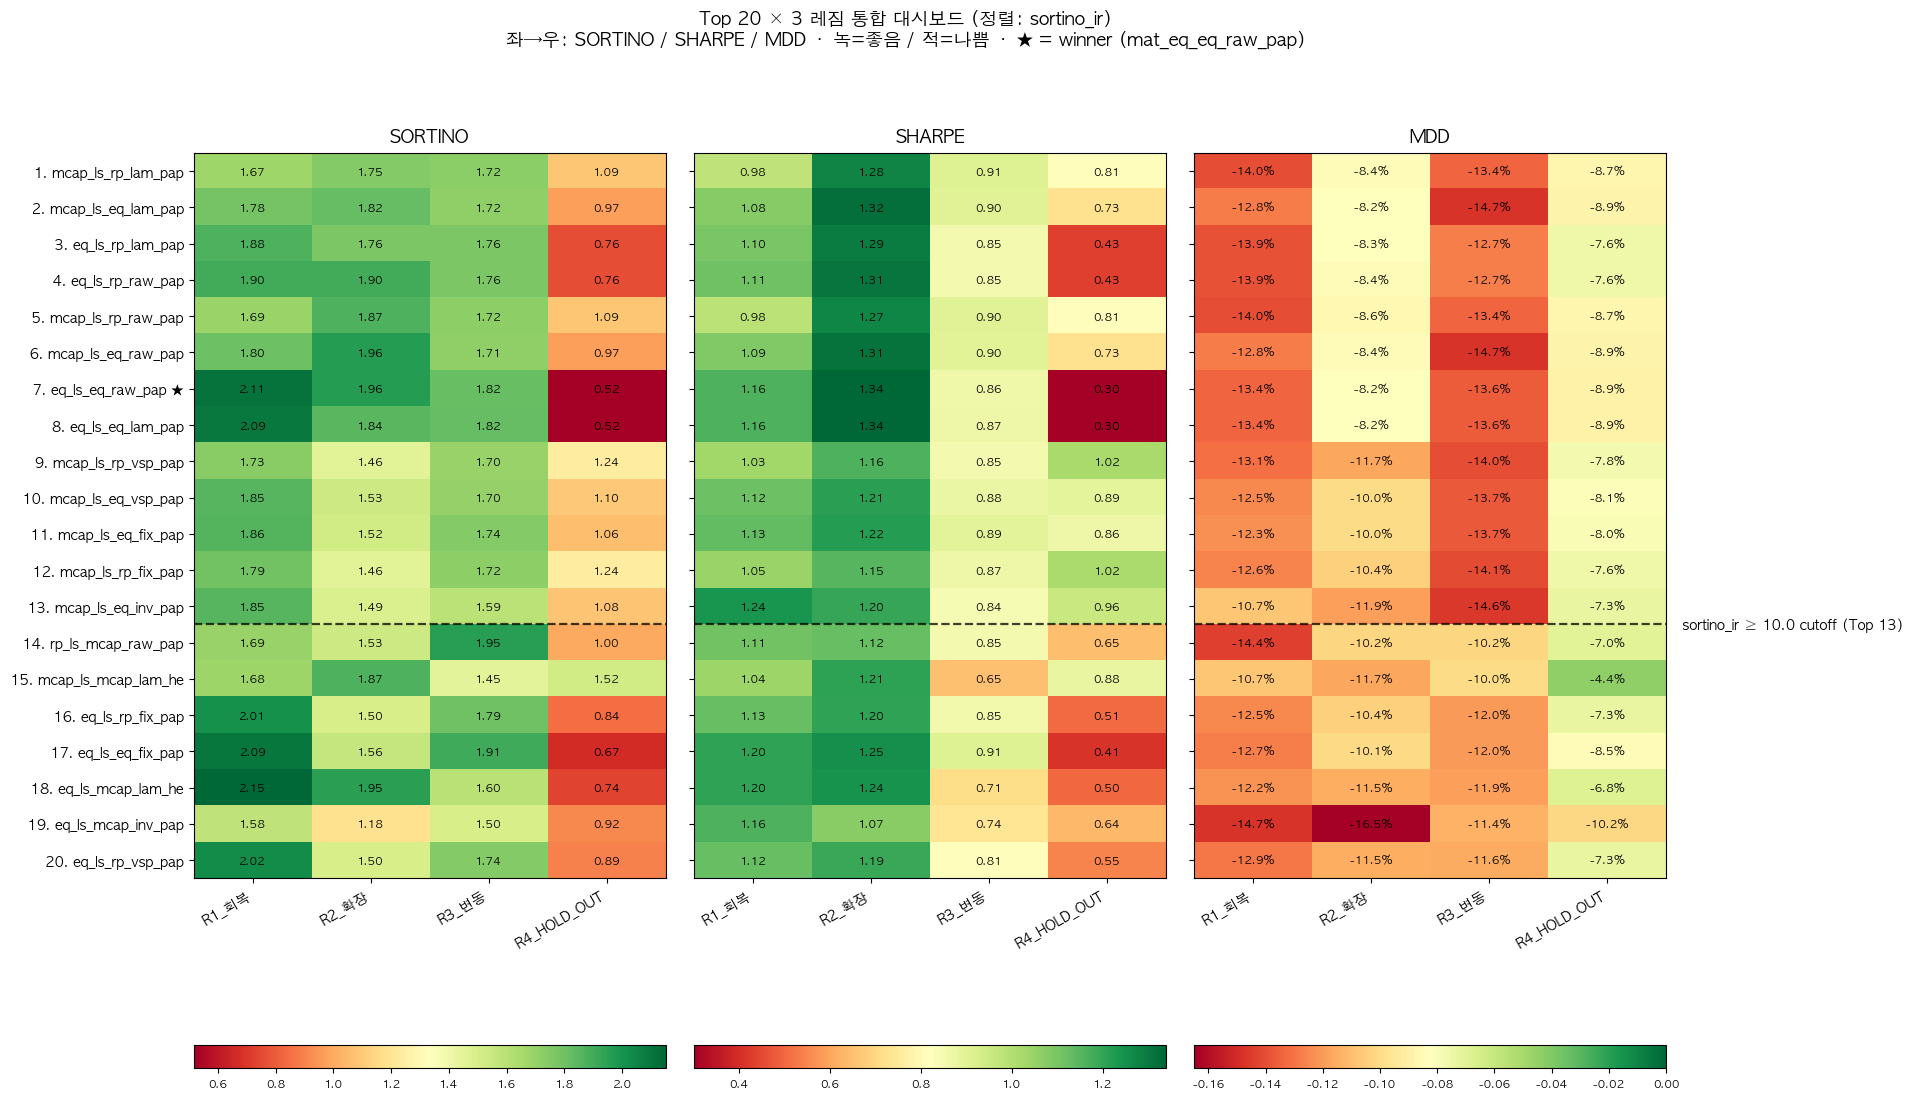

In [3]:
# ── §2. sortino_ir Top 20 dashboard (4-레짐) ────────────────
import importlib, analyze_plots
importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== §2. sortino_ir 정렬 Top 20 (4-레짐 × 3 metric 히트맵) ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    regime_labels=REGIME_LABELS_4,
    save_path=OUT_DIR / 'B_sortino_ir_dashboard.png',
    winner_name=WINNER_NAME,
    threshold_rank=N_STABLE,
    threshold_label=f'sortino_ir ≥ {WINNER_IR_THRESHOLD} cutoff (Top {N_STABLE})',
)

top20_si = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20_si.index += 1
print('\n■ §2 행 매핑 (sortino_ir 큰 순)')
display(top20_si[['canonical','sortino_ir','sortino_mean','sortino_std','sortino_full','mdd_worst']].round(3))


## §3. Winner 자동 동기화 + R4 hold-out 검증 + SPY 벤치마크 ⭐

**목적**: 05b §4.2 와 동일 기준 (3-레짐 K_CUT sortino_ir ≥ 10 + sortino_TEST max) 으로 식별된 winner 를 4-레짐 + 192m 환경에서 검증.

- 3-레짐 (R1/R2/R3) 는 05b 와 동일한 K_CUT 적용 → sortino_ir 값이 05b 와 1:1 동일.
- WINNER 변수는 §1 에서 정의된 `WINNER_NAME` 재사용 (05b 와 자동 동기화, 하드코딩 없음).
- R4 sortino rank 가 상위 25% 안이면 hold-out 검증 통과로 간주.
- **SPY R4 벤치마크 비교** — winner 가 시장 대비 outperform/underperform 인지 명시.


In [4]:
# ── §3. winner 자동 동기화 결과 + R4 hold-out 검증 ─────────────────
# WINNER_NAME / N_STABLE / WINNER_IR_THRESHOLD 는 Cell 3 에서 이미 정의됨
WINNER = WINNER_NAME   # 본 셀 내부 호환 alias
print(f'■ §3. Auto-sync winner: {WINNER}')
print(f'   기준 1: 3-레짐 K_CUT sortino_ir ≥ {WINNER_IR_THRESHOLD} — 통과 {N_STABLE}개')
_cand = mt[mt['name'].isin(_stable_names)].sort_values('sortino_TEST', ascending=False) if N_STABLE > 0 else mt.sort_values('sortino_TEST', ascending=False)
print(f'   기준 2: sortino_TEST (168m, K_CUT 2023-12) max — {_cand.iloc[0]["sortino_TEST"]:.3f}')

# 4-레짐 (192m) 환경에서 winner 위치
w = rt[rt['name']==WINNER].iloc[0]
sf_rank = (rt['sortino_full'] > w['sortino_full']).sum() + 1
si_rank = (rt['sortino_ir']   > w['sortino_ir']).sum()   + 1

print(f'\n■ §3.1 4-레짐 환경에서의 winner 위치')
print(f'   sortino_full (192m)            = {w["sortino_full"]:.3f} (rank {sf_rank}/{len(rt)})')
print(f'   sortino_ir   (R1-R3 K_CUT)     = {w["sortino_ir"]:.3f} (rank {si_rank}/{len(rt)})')

# 4-레짐별 sortino/sharpe/mdd 표
print(f'\n■ §3.2 4-레짐별 winner 성과 (sortino / sharpe / mdd)')
print(f'   {"레짐":<14} {"sortino":>9} {"sharpe":>9} {"mdd":>9}')
for lbl in REGIME_LABELS_4:
    s = w.get(f'sortino_{lbl}', np.nan)
    h = w.get(f'sharpe_{lbl}',  np.nan)
    m = w.get(f'mdd_{lbl}',     np.nan)
    s_str = f'{s:>9.3f}' if pd.notna(s) else f'{"NaN":>9}'
    h_str = f'{h:>9.3f}' if pd.notna(h) else f'{"NaN":>9}'
    m_str = f'{m*100:>7.2f}%' if pd.notna(m) else f'{"NaN":>8}'
    print(f'   {lbl:<14} {s_str} {h_str} {m_str}')

# R4 HOLD_OUT 검증 — 24m 실전 hold-out 에서 rank
r4_col = 'sortino_R4_HOLD_OUT'
_r4_valid = rt[r4_col].notna()
r4_rank = (rt.loc[_r4_valid, r4_col] > w[r4_col]).sum() + 1
r4_n = _r4_valid.sum()
r4_pct = r4_rank / r4_n if r4_n > 0 else float('nan')

print(f'\n■ §3.3 R4 HOLD_OUT 결과 — 2024-01 ~ 2025-12 (24m)')
print(f'   레짐 환경: AI 랠리 포함 상승장 (SPY +50%↑), 저변동 anomaly cyclical 약점 구간')
print(f'   sortino_R4_HOLD_OUT = {w[r4_col]:.3f}  (rank {r4_rank}/{r4_n}, 상위 {r4_pct*100:.1f}%)')
if r4_pct <= 0.25:
    verdict = '✅ 상위 25% — hold-out 에서도 견딤 (out-of-sample 검증 통과)'
elif r4_pct <= 0.5:
    verdict = '⚠️ 상위 25~50% — 평균 수준'
else:
    verdict = '❌ 하위 50% — 저변동 anomaly 의 AI 랠리 한계 (Frazzini-Pedersen 2014 §5: 고변동 모멘텀 강세장 후반에 저변동 전략 underperform)'
print(f'   → {verdict}')

# ── SPY R4 벤치마크 비교 (winner R4 의 절대 hold-out 성과) ──
from master_table import _sortino_subperiod
spy_r4 = _sortino_subperiod(spy_ret, rf, R4_HOLDOUT[1], R4_HOLDOUT[2])
winner_r4 = w[r4_col]
gap = winner_r4 - spy_r4

print(f'\n■ §3.4 R4 hold-out 벤치마크 비교 (SPY 대비 winner)')
print(f'   SPY    R4 sortino = {spy_r4:.3f}  (AI 랠리 포함 상승장 → 시장은 강함)')
print(f'   winner R4 sortino = {winner_r4:.3f}')
print(f'   gap                = {gap:+.3f}  → winner {"outperform" if gap > 0 else "underperform"} SPY')
if gap < 0:
    print(f'   ↳ 저변동 anomaly 의 cyclical 한계: 상승장 SPY 가 강할 때 winner 가 따라가지 못함 (Frazzini-Pedersen 2014)')


■ §3. Auto-sync winner: mat_eq_eq_raw_pap
   기준 1: 3-레짐 K_CUT sortino_ir ≥ 10.0 — 통과 13개
   기준 2: sortino_TEST (168m, K_CUT 2023-12) max — 1.853

■ §3.1 4-레짐 환경에서의 winner 위치
   sortino_full (192m)            = 1.691 (rank 4/90)
   sortino_ir   (R1-R3 K_CUT)     = 16.500 (rank 7/90)

■ §3.2 4-레짐별 winner 성과 (sortino / sharpe / mdd)
   레짐               sortino    sharpe       mdd
   R1_회복              2.109     1.164  -13.40%
   R2_확장              1.962     1.339   -8.20%
   R3_변동              1.818     0.864  -13.60%
   R4_HOLD_OUT        0.516     0.300   -8.95%

■ §3.3 R4 HOLD_OUT 결과 — 2024-01 ~ 2025-12 (24m)
   레짐 환경: AI 랠리 포함 상승장 (SPY +50%↑), 저변동 anomaly cyclical 약점 구간
   sortino_R4_HOLD_OUT = 0.516  (rank 88/90, 상위 97.8%)
   → ❌ 하위 50% — 저변동 anomaly 의 AI 랠리 한계 (Frazzini-Pedersen 2014 §5: 고변동 모멘텀 강세장 후반에 저변동 전략 underperform)

■ §3.4 R4 hold-out 벤치마크 비교 (SPY 대비 winner)
   SPY    R4 sortino = 2.310  (AI 랠리 포함 상승장 → 시장은 강함)
   winner R4 sortino = 0.516
   gap                = -1.794  → 